# Effective capacity: comparing fault levels at $D \to \infty$

This notebook shows that the recovery of the capacity retained $\eta/N$ does not depend on the details of what funcitonal form is used to represent the N-dependance of FHT performance.

First, we use the scaling law fits to subtract the data-dependance from the (L, N, D, p) data, resulting in an effective (L, N, p) dataset.

Then we project this (L, N, p) dataset back onto the $p=0$ law to find values of $\eta$ for each point.

Scatters of this "model-free" eta reveal the same patterns that are shown in Fig. 1. Note that this analysis is equivalent to showing that the residuals of the scaling law fit are unstructered, which is explored a few other notebooks in this folder.

In [1]:
import os, sys

# Repo root on the path (for `nano_llama` and `scaling_law`), from either cwd.
_HERE = os.getcwd()
for _cand in (_HERE, os.path.dirname(_HERE)):
    if os.path.isdir(os.path.join(_cand, "nano_llama")) and _cand not in sys.path:
        sys.path.insert(0, _cand)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.style.use("default")

import scaling_law as est
from scaling_law import data_loading as dl

# ---------------------------------------------------------------------------------- # <-- SET
PROCESSED_DIR = "/mnt/storage/eval_summaries/training_2026-08-26-11-43-09"
K = None                     # None -> require exactly one k_train in the data and use it
MAX_P = 0.2                  # keep cohorts with p_train <= this (None keeps all)

FIXED_E = 1.55               # the floor, PINNED on every cohort (an input, never fitted)
ALPHA2_CLEAN = 0.0           # clean cohort: plain power law in N (this law is what gets inverted)
ALPHA2_FAULTED = None        # faulted cohorts: curvature fitted

SCREEN = dict(max_ceiling_frac=1.0, min_ne_frac=0.5, min_tpp=5)

NCOL_GRID = 4                # panels per row in the two figures
# ---------------------------------------------------------------------------------------------

cohorts = dl.load_matched_results(PROCESSED_DIR, k=K)
k_used = float(cohorts[next(iter(cohorts))][0].k_train)
if MAX_P is not None:
    cohorts = {p: v for p, v in cohorts.items() if p <= MAX_P}
pop, _filt = dl.filter_cohorts(cohorts, **SCREEN)

arr = {}
for p in sorted(pop):
    a = dl.eval_cohort_arrays(pop[p])
    a["eval_se"] = np.array([r.eval_se for r in pop[p]], dtype=float)
    arr[p] = a

P_VALUES = np.array(sorted(arr), dtype=float)
P0 = float(P_VALUES.min())                       # the clean reference cohort
_cmap = plt.get_cmap("viridis")
cohort_color = {p: _cmap(0.88 * (p - P_VALUES.min()) / max(1e-12, np.ptp(P_VALUES)))
                for p in P_VALUES}

if FIXED_E >= min(a["L"].min() for a in arr.values()):
    raise ValueError(f"FIXED_E = {FIXED_E} is at or above the lowest measured loss; no surface can "
                     f"have a floor above its own data.")

print(f"{sum(len(a['L']) for a in arr.values())} runs across {len(arr)} cohorts, k_train = {k_used:g}")
print(f"  E = {FIXED_E:g} pinned on every cohort | N = total params | "
      f"alpha2: clean {ALPHA2_CLEAN}, faulted {'free' if ALPHA2_FAULTED is None else ALPHA2_FAULTED}")
print(f"  p = {', '.join(f'{p:g}' for p in P_VALUES)}")

1810 runs across 17 cohorts, k_train = 4
  E = 1.55 pinned on every cohort | N = total params | alpha2: clean 0.0, faulted free
  p = 0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2


In [2]:
# ---- one fit per cohort, then L_inf = L - (that cohort's fitted D-term) -----------------------
fits = {p: est.fit(a["N"], a["D"], a["L"], fix_E=FIXED_E,
                   fix_alpha2=(ALPHA2_CLEAN if p == P0 else ALPHA2_FAULTED))
        for p, a in arr.items()}
clean = fits[P0]                                  # every L_inf is inverted through this one


def invert_to_N_eff(fit, L_inf):
    """Size whose SATURATED loss equals `L_inf`, under `fit`'s N-term. NaN where unreachable.

    Quadratic in u = log(N/N0), since with curvature the N-term is a Gaussian in log-size:
        L_inf - E = exp(a - alpha1*u - alpha2*u**2)
    Taking the root on the monotone branch, in the cancellation-free form that stays EXACT as
    alpha2 -> 0 (where it reduces to u = (a - log(gap)) / alpha1)."""
    gap = np.asarray(L_inf, dtype=float) - fit.E
    with np.errstate(invalid="ignore", divide="ignore"):
        c = np.log(gap) - fit.a
        disc = fit.alpha1 ** 2 - 4.0 * fit.alpha2 * c
        ne = fit.N0 * np.exp(-2.0 * c / (fit.alpha1 + np.sqrt(disc)))
    return np.where((gap > 0) & (disc >= 0), ne, np.nan)


# Round-trip guard: inverting the clean law's own saturated loss must return the size it
# was evaluated at. Holds at any curvature, which is why it is the whole check.
_Ng = np.array([1e7, 1e8, 5e8])
assert np.allclose(invert_to_N_eff(clean, clean.saturated_loss(_Ng)), _Ng, rtol=1e-9)

eff = {}
for p, a in arr.items():
    L_inf = a["L"] - fits[p].d_term(a["D"])
    eff[p] = dict(N=a["N"], D=a["D"], L=a["L"], size=a["size"], L_inf=L_inf,
                  ratio=invert_to_N_eff(clean, L_inf) / a["N"])


def by_arch(e, min_points=1):
    """{architecture label: indices into `e`} -- runs sharing an N and differing only in D."""
    out = {}
    for i, s in enumerate(e["size"]):
        out.setdefault(str(s), []).append(i)
    return {s: np.array(ix) for s, ix in sorted(out.items()) if len(ix) >= min_points}


# Architecture colour = MODEL SIZE, on one log scale shared by every panel, so a colour means
# the same N everywhere and the colorbar reads for the whole figure. Ranking the families and
# spreading a ramp over them instead would give the same colour to different N in panels whose
# cohorts kept different architectures.
N_CMAP = plt.get_cmap("plasma")
_alln = np.concatenate([e["N"] for e in eff.values()])
N_NORM = LogNorm(vmin=_alln.min(), vmax=_alln.max())
N_MAPPABLE = plt.cm.ScalarMappable(norm=N_NORM, cmap=N_CMAP)


def grid(n, ncol=None, w=3.1, h=2.7):
    """A (nrow, ncol) panel grid sized for `n` cohorts, with the unused axes hidden."""
    ncol = ncol or NCOL_GRID
    ncol = min(ncol, n)
    nrow = int(np.ceil(n / ncol))
    fig, axs = plt.subplots(nrow, ncol, figsize=(w * ncol, h * nrow), squeeze=False)
    flat = axs.ravel()
    for ax in flat[n:]:
        ax.set_visible(False)
    return fig, flat


print(f"{'cohort':<10}{'alpha1':>9}{'alpha2':>10}{'beta1':>9}{'median N_eff/N':>17}")
for p in sorted(fits):
    f = fits[p]
    print(f"{f'p={p:g}':<10}{f.alpha1:>9.4f}{f.alpha2:>+10.5f}{f.beta1:>9.4f}"
          f"{np.nanmedian(eff[p]['ratio']):>17.3f}")

cohort       alpha1    alpha2    beta1   median N_eff/N
p=0          0.1874  +0.00000   0.4285            0.999
p=0.005      0.1882  +0.00098   0.4275            0.840
p=0.01       0.1895  +0.00173   0.4149            0.815
p=0.015      0.1857  +0.00500   0.4280            0.709
p=0.02       0.1844  +0.00441   0.4261            0.649
p=0.025      0.1899  +0.00402   0.4016            0.687
p=0.03       0.1807  +0.00767   0.4171            0.605
p=0.035      0.1847  +0.00579   0.4102            0.591
p=0.04       0.1795  +0.00638   0.4218            0.546
p=0.06       0.1776  +0.00981   0.3979            0.522
p=0.08       0.1753  +0.00976   0.3833            0.482
p=0.1        0.1740  +0.01126   0.3625            0.474
p=0.12       0.1650  +0.01242   0.3771            0.386
p=0.14       0.1650  +0.01208   0.3615            0.366
p=0.16       0.1626  +0.01467   0.3396            0.399
p=0.18       0.1562  +0.01326   0.3500            0.327
p=0.2        0.1552  +0.01506   0.3305          

## Collapse: $L^{\infty}$ against $D$

Subtract the D-dependance from the raw loss data using the fit law. The resulting effective dataset should have minimal D-dependance

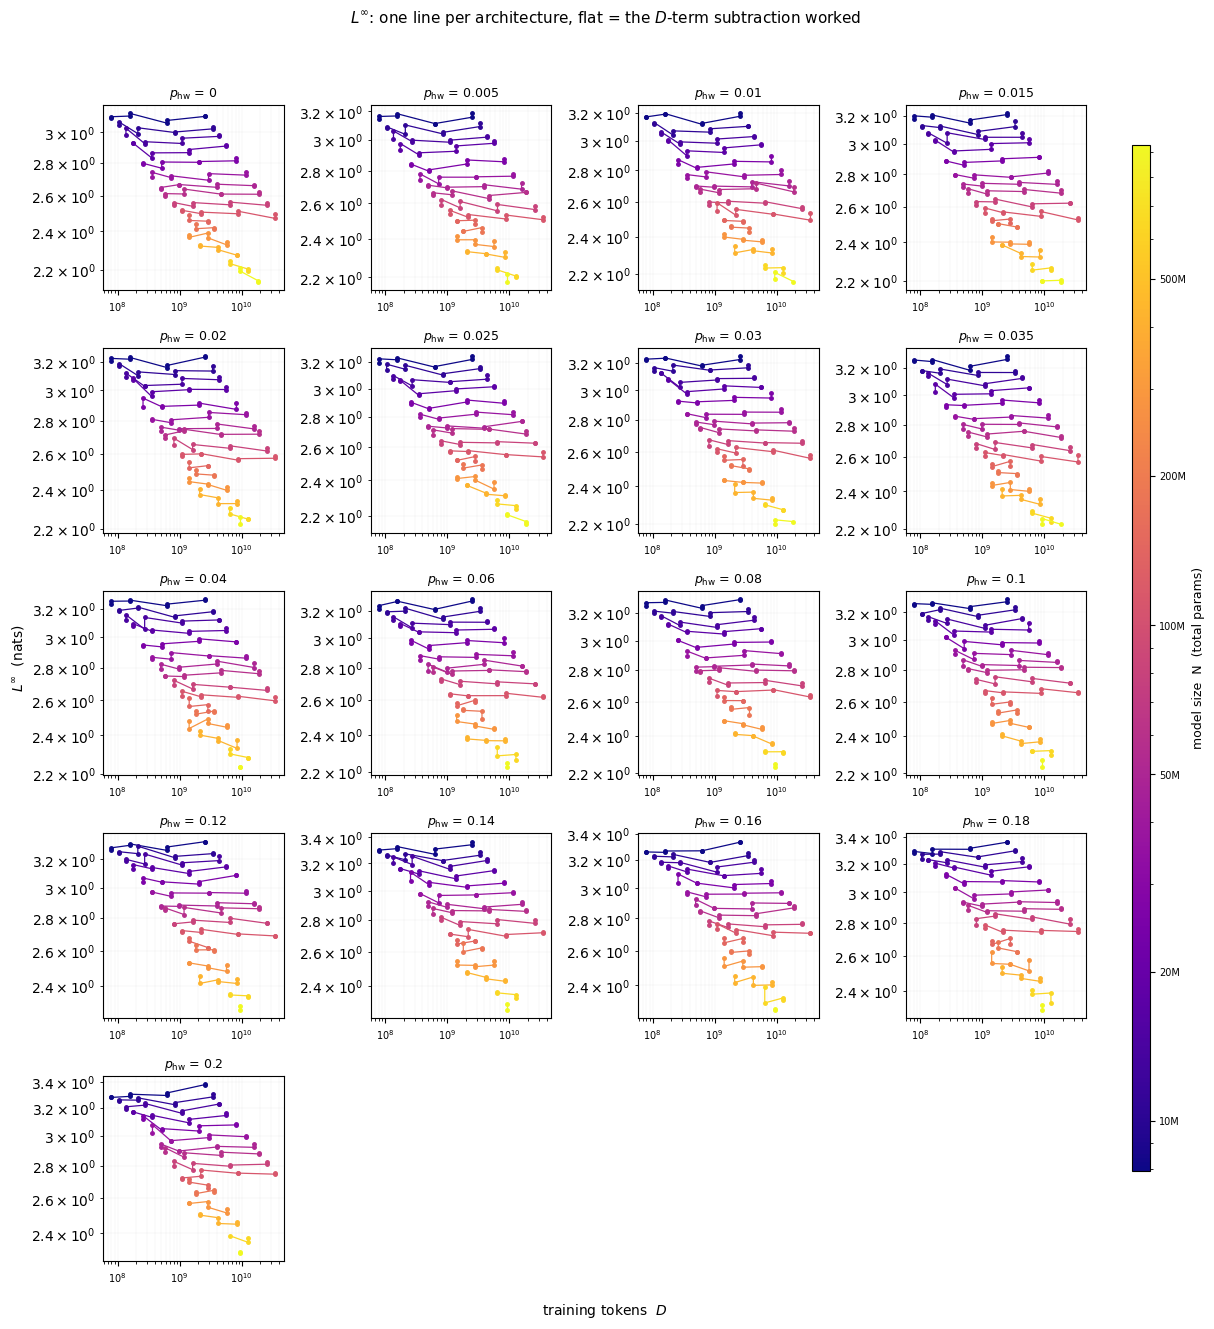

In [4]:
SHOW_RAW = False                      # True -> measured L instead of L_inf   # <-- SET

key = "L" if SHOW_RAW else "L_inf"
ps = sorted(eff)
fig, axs = grid(len(ps))
for ax, p in zip(axs, ps):
    e = eff[p]
    for s, ix in by_arch(e, min_points=2).items():
        o = ix[np.argsort(e["D"][ix])]
        ax.plot(e["D"][o], e[key][o], "o-", ms=2.5, lw=0.9,
                color=N_CMAP(N_NORM(e["N"][ix][0])))      # one N per family, so one colour
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(rf"$p_\mathrm{{hw}}$ = {p:g}", fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2, which="both", lw=0.3)
fig.supxlabel("training tokens  $D$", fontsize=10)
fig.supylabel("measured loss  $L$" if SHOW_RAW else r"$L^{\infty}$  (nats)", fontsize=10)
fig.suptitle(("measured loss -- each architecture fans out with $D$" if SHOW_RAW else
              r"$L^{\infty}$: one line per architecture, flat = the $D$-term subtraction worked"),
             fontsize=11)
# Leave a strip on the right for the colorbar, then place it in its own axes -- `tight_layout` and a
# colorbar that steals space from 12 subplots fight each other otherwise.
fig.tight_layout(rect=[0, 0, 0.90, 0.96])
cax = fig.add_axes([0.925, 0.12, 0.014, 0.76])
cb = fig.colorbar(N_MAPPABLE, cax=cax)
# Decade ticks alone label only 1e7 / 1e8 over this ladder, which is too coarse to read a line's N
# off. Tick the 1-2-5 points inside the actual range instead, labelled in M/B.
_dec = [m * 10 ** k for k in range(6, 11) for m in (1, 2, 5)]
_ticks = [t for t in _dec if N_NORM.vmin <= t <= N_NORM.vmax]
cb.set_ticks(_ticks)
cb.set_ticklabels([f"{t/1e9:g}B" if t >= 1e9 else f"{t/1e6:g}M" for t in _ticks])
cb.set_label("model size  N  (total params)", fontsize=9)
cb.ax.tick_params(labelsize=7)
plt.show()

## Capacity retained: $N_{\mathrm{eff}}/N$ against $N$

Plot the $\eta$ values for the effective dataset vs $p$ and $N$

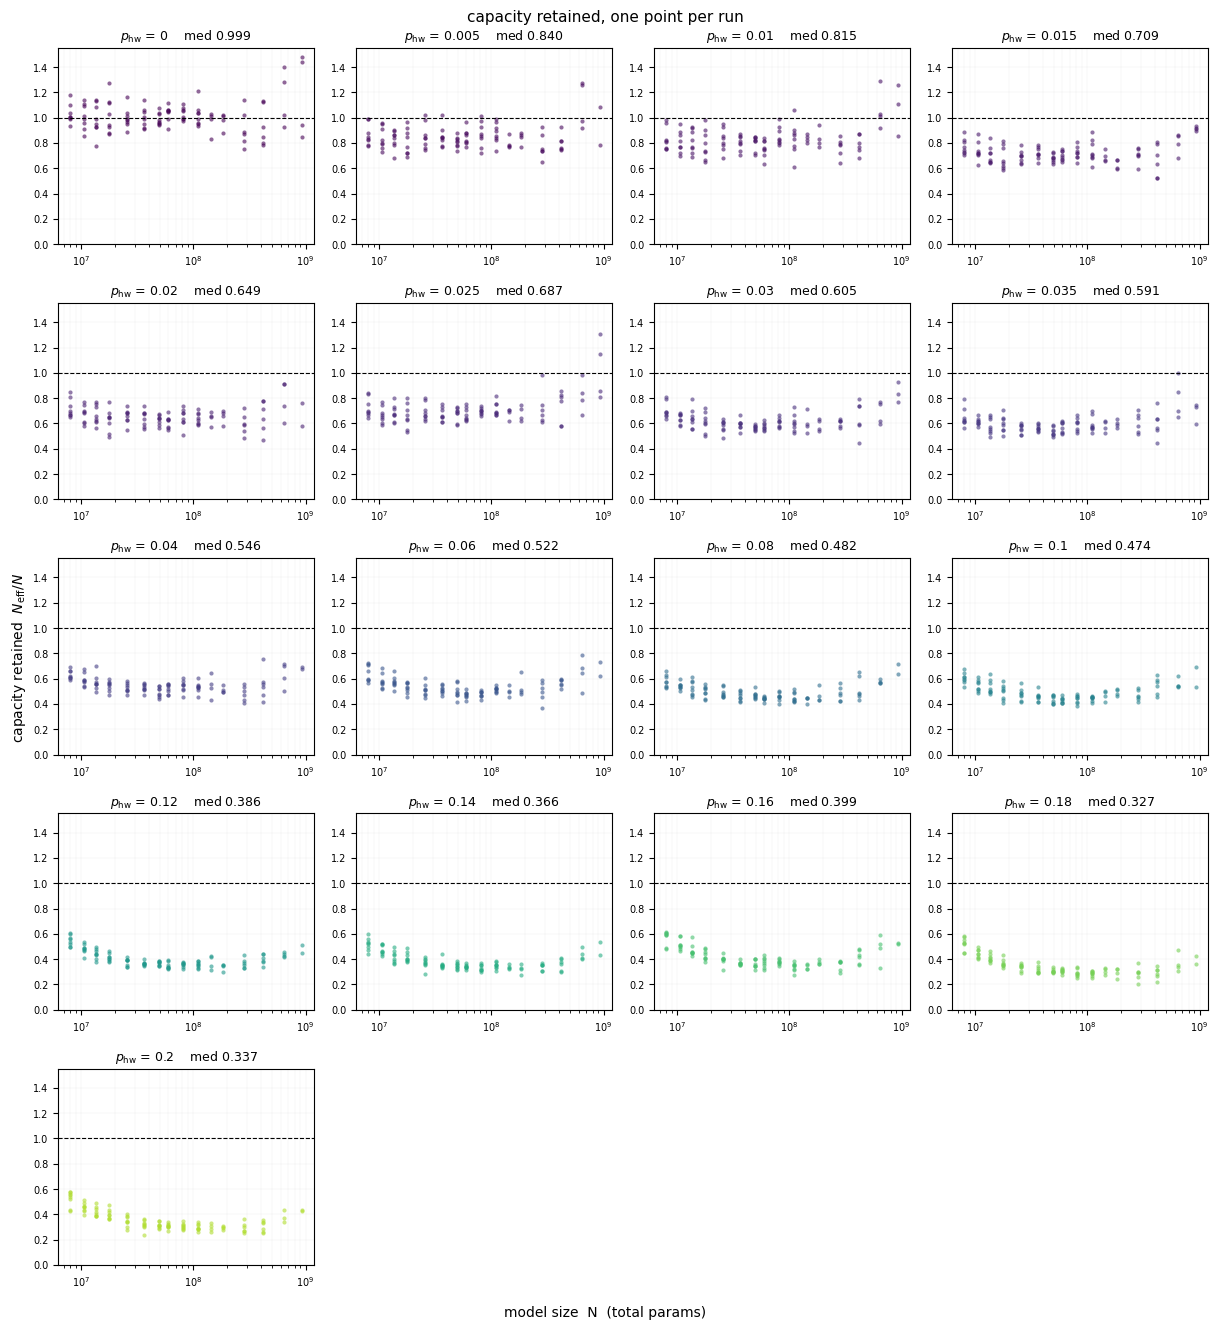

In [5]:
ps = sorted(eff)
fig, axs = grid(len(ps))
ylo = min(np.nanmin(eff[p]["ratio"]) for p in ps)
yhi = max(np.nanmax(eff[p]["ratio"]) for p in ps)
for ax, p in zip(axs, ps):
    e = eff[p]
    ax.scatter(e["N"], e["ratio"], s=9, color=cohort_color[p], alpha=0.6, lw=0)
    ax.axhline(1.0, color="k", ls="--", lw=0.8)
    ax.set_xscale("log")
    ax.set_ylim(min(0.95 * ylo, 0.0), max(1.05 * yhi, 1.05))
    ax.set_title(rf"$p_\mathrm{{hw}}$ = {p:g}    med {np.nanmedian(e['ratio']):.3f}", fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2, which="both", lw=0.3)
fig.supxlabel("model size  N  (total params)", fontsize=10)
fig.supylabel(r"capacity retained  $N_\mathrm{eff}/N$", fontsize=10)
fig.suptitle(r"capacity retained, one point per run", fontsize=11)
fig.tight_layout()
plt.show()